# Project 1: E-Commerce Intelligence — Step 2: Churn & Conversion Classification

> **Branch:** `feature/churn-classification`  ·  **Dataset:** Olist Brazilian E-Commerce  
> **Task:** Binary classification — predict (1) order delivery success and (2) customer churn

---

## Pipeline Overview

| # | Section | Description |
|---|---|---|
| 0 | Setup & Imports | Libraries, constants, global config |
| 1 | Load Data | Preprocessed feature matrices + raw engineered splits |
| 2 | Define Targets | Conversion (delivery) and Churn (repeat purchase) labels |
| 3 | Class Imbalance | SMOTE oversampling on training set only |
| 4 | Evaluation Helper | Unified metrics function |
| 5 | Baseline Models | Logistic Regression, KNN, Naive Bayes |
| 6 | Advanced Models | Decision Tree, Random Forest, AdaBoost, XGBoost, LightGBM |
| 7 | Hyperparameter Tuning | RandomizedSearchCV with imblearn Pipeline |
| 8 | Ensemble Methods | Voting Classifier + Stacking Classifier |
| 9 | Validation Comparison | Side-by-side model leaderboard |
| 10 | Threshold Optimization | F1-optimized decision boundary per target |
| 11 | Test Set Evaluation | Final held-out metrics & classification reports |
| 12 | Evaluation Curves | ROC-AUC & Precision-Recall plots |
| 13 | Model Persistence | Save models, thresholds, features to `models/` |
| 14 | Inference Pipeline | End-to-end prediction + business actions |

## Section 0 — Setup & Imports

In [1]:
# ── Standard Library ──────────────────────────────────────────────────────────
import os
import warnings
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Visualisation ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)

# ── Scikit-Learn: Preprocessing & Feature Selection ───────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

# ── GPU-Accelerated Models (RAPIDS cuML with Scikit-Learn fallback wrappers) ──
import cuml
cuml.set_global_output_type('numpy')

from cuml.linear_model       import LogisticRegression as CuLogisticRegression
from cuml.neighbors          import KNeighborsClassifier as CuKNeighborsClassifier
from cuml.naive_bayes        import GaussianNB as CuGaussianNB
from cuml.ensemble           import RandomForestClassifier as CuRandomForestClassifier

class LogisticRegression(CuLogisticRegression):
    def __init__(self, random_state=None, **kwargs):
        super().__init__(**kwargs)

class KNeighborsClassifier(CuKNeighborsClassifier):
    def __init__(self, n_jobs=None, **kwargs):
        super().__init__(**kwargs)

class GaussianNB(CuGaussianNB):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

class RandomForestClassifier(CuRandomForestClassifier):
    def __init__(self, n_jobs=None, class_weight=None, **kwargs):
        super().__init__(**kwargs)

class DecisionTreeClassifier(CuRandomForestClassifier):
    def __init__(self, max_depth=None, random_state=None, class_weight=None, **kwargs):
        super().__init__(n_estimators=1, max_depth=max_depth, random_state=random_state, **kwargs)

from sklearn.ensemble        import (AdaBoostClassifier,
                                     VotingClassifier,
                                     StackingClassifier)

# ── Scikit-Learn: Model Selection & Metrics ───────────────────────────────────
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics         import (classification_report, f1_score,
                                     roc_curve, auc,
                                     precision_recall_curve,
                                     ConfusionMatrixDisplay)
from sklearn.base            import clone, BaseEstimator, TransformerMixin

# ── Gradient Boosting (GPU) ────────────────────────────────────────────────────
from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier

# ── Imbalanced-Learn ──────────────────────────────────────────────────────────
from imblearn.over_sampling  import SMOTE
from imblearn.pipeline       import Pipeline as ImbPipeline

# ── Persistence ───────────────────────────────────────────────────────────────
import joblib

# ── Constants ─────────────────────────────────────────────────────────────────
OUTPUT_DIR = 'outputs'
MODEL_DIR  = 'models'
PLOT_DIR   = 'plots'
SEED       = 42

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PLOT_DIR,  exist_ok=True)

# Compatibility shim (pandas ≥ 2.x removed is_interval from public API)
if not hasattr(pd.api.types, 'is_interval'):
    pd.api.types.is_interval = lambda x: isinstance(x, pd.Interval)

print('All imports successful ✓')

All imports successful ✓


## Section 1 — Load Preprocessed Feature Matrices

In [2]:
print('Loading preprocessed feature matrices...')

X_train = pd.read_csv(os.path.join(OUTPUT_DIR, 'X_train_processed.csv.gz'), index_col=0)
X_val   = pd.read_csv(os.path.join(OUTPUT_DIR, 'X_val_processed.csv.gz'),   index_col=0)
X_test  = pd.read_csv(os.path.join(OUTPUT_DIR, 'X_test_processed.csv.gz'),  index_col=0)

train_raw = pd.read_csv(os.path.join(OUTPUT_DIR, 'train_raw_engineered.csv.gz'), index_col=0)
val_raw   = pd.read_csv(os.path.join(OUTPUT_DIR, 'val_raw_engineered.csv.gz'),   index_col=0)
test_raw  = pd.read_csv(os.path.join(OUTPUT_DIR, 'test_raw_engineered.csv.gz'),  index_col=0)

print(f'  X_train : {X_train.shape}')
print(f'  X_val   : {X_val.shape}')
print(f'  X_test  : {X_test.shape}')

assert X_train.shape[0] == train_raw.shape[0], 'Train row mismatch!'
assert X_val.shape[0]   == val_raw.shape[0],   'Val row mismatch!'
assert X_test.shape[0]  == test_raw.shape[0],  'Test row mismatch!'
print('Row alignment verified ✓')

Loading preprocessed feature matrices...


  X_train : (90817, 78)
  X_val   : (11331, 78)
  X_test  : (11277, 78)
Row alignment verified ✓


## Section 2 — Define Targets

| Target | Label 1 | Label 0 |
|---|---|---|
| **Conversion** | `order_status == 'delivered'` (successful fulfilment) | All other statuses |
| **Churn** | Customer never ordered again (one-time buyer) | Repeat customer |

In [3]:
# ── Conversion target: delivered vs not ───────────────────────────────────────
y_train_conv = (train_raw['order_status'] == 'delivered').astype(int).values
y_val_conv   = (val_raw['order_status']   == 'delivered').astype(int).values
y_test_conv  = (test_raw['order_status']  == 'delivered').astype(int).values

# ── Churn target: one-time buyer (1) vs repeat customer (0) ───────────────────
# A customer churns if their unique_id appears only once across the full dataset
all_customers   = pd.concat([train_raw, val_raw, test_raw])
repeat_ids      = set(
    all_customers.groupby('customer_unique_id')
    .filter(lambda g: len(g) > 1)['customer_unique_id']
)

def churn_flag(raw_split):
    return (~raw_split['customer_unique_id'].isin(repeat_ids)).astype(int).values

y_train_churn = churn_flag(train_raw)
y_val_churn   = churn_flag(val_raw)
y_test_churn  = churn_flag(test_raw)

# ── Summary ───────────────────────────────────────────────────────────────────
for name, y_tr, y_v, y_te in [
    ('Conversion', y_train_conv,  y_val_conv,   y_test_conv),
    ('Churn',      y_train_churn, y_val_churn,  y_test_churn),
]:
    pos_pct = y_tr.mean() * 100
    print(f'{name:12s} | Train pos: {pos_pct:.1f}% '
          f'| Val pos: {y_v.mean()*100:.1f}% '
          f'| Test pos: {y_te.mean()*100:.1f}%')

Conversion   | Train pos: 97.2% | Val pos: 97.1% | Test pos: 97.1%
Churn        | Train pos: 74.1% | Val pos: 74.2% | Test pos: 75.2%


## Section 3 — Handle Class Imbalance (SMOTE)

SMOTE (Synthetic Minority Over-sampling Technique) is applied **only on the training set** to avoid leaking distribution information into validation or test sets.

In [4]:
smote = SMOTE(random_state=SEED)

print('Applying SMOTE to training sets...')

# Conversion
X_train_conv_bal, y_train_conv_bal   = smote.fit_resample(X_train, y_train_conv)
print(f'  Conversion — before: {np.bincount(y_train_conv)} | after: {np.bincount(y_train_conv_bal)}')

# Churn
X_train_churn_bal, y_train_churn_bal = smote.fit_resample(X_train, y_train_churn)
print(f'  Churn      — before: {np.bincount(y_train_churn)} | after: {np.bincount(y_train_churn_bal)}')

# Convenience: raw (non-SMOTE) val / test splits per target
X_val_conv,   y_val_conv   = X_val,   y_val_conv
X_test_conv,  y_test_conv  = X_test,  y_test_conv
X_val_churn,  y_val_churn  = X_val,   y_val_churn
X_test_churn, y_test_churn = X_test,  y_test_churn

print('SMOTE complete ✓')

Applying SMOTE to training sets...


  Conversion — before: [ 2578 88239] | after: [88239 88239]


  Churn      — before: [23554 67263] | after: [67263 67263]
SMOTE complete ✓


## Section 4 — Evaluation Helper

In [5]:
def evaluate_model(model, X_tr, y_tr, X_val, y_val,
                   model_name: str, target_name: str) -> dict:
    """
    Fit model on (X_tr, y_tr), evaluate on (X_val, y_val).
    Returns a dict of key classification metrics.
    """
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1] if hasattr(model, 'predict_proba') else None

    f1_mac = f1_score(y_val, y_pred, average='macro',    zero_division=0)
    f1_0   = f1_score(y_val, y_pred, pos_label=0,        zero_division=0)
    f1_1   = f1_score(y_val, y_pred, pos_label=1,        zero_division=0)

    pr_auc = 0.0
    if y_proba is not None:
        prec, rec, _ = precision_recall_curve(y_val, y_proba)
        pr_auc = auc(rec, prec)

    return {
        'Target':     target_name,
        'Model':      model_name,
        'F1-Macro':   round(f1_mac, 4),
        'F1-Class0':  round(f1_0,   4),
        'F1-Class1':  round(f1_1,   4),
        'PR-AUC':     round(pr_auc, 4),
    }

# Result accumulators
conv_results  = []
churn_results = []

print('Helper ready ✓')

Helper ready ✓


## Section 5 — Baseline Models

In [6]:
baselines = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced',
                                               random_state=SEED),
    'k-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Naive Bayes':         GaussianNB(),
}

print('Training baseline models...')
for name, model in baselines.items():
    r_conv  = evaluate_model(model, X_train_conv_bal,  y_train_conv_bal,
                              X_val_conv,  y_val_conv,  name, 'Conversion')
    r_churn = evaluate_model(model, X_train_churn_bal, y_train_churn_bal,
                              X_val_churn, y_val_churn, name, 'Churn')
    conv_results.append(r_conv)
    churn_results.append(r_churn)
    print(f'  {name:25s} | Conv F1-Macro={r_conv["F1-Macro"]:.4f} '
          f'| Churn F1-Macro={r_churn["F1-Macro"]:.4f}')

print('Baselines done ✓')

Training baseline models...


  Logistic Regression       | Conv F1-Macro=0.4751 | Churn F1-Macro=0.9211


  k-Nearest Neighbors       | Conv F1-Macro=0.5113 | Churn F1-Macro=0.5783


  Naive Bayes               | Conv F1-Macro=0.4870 | Churn F1-Macro=0.5437
Baselines done ✓


## Section 6 — Advanced & Boosting Models

In [7]:
# Class-weight ratio for XGBoost (handles imbalance natively)
neg, pos      = np.bincount(y_train_churn)
weight_ratio  = neg / pos

advanced_models = {
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10, class_weight='balanced', random_state=SEED),

    'Random Forest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced',
        random_state=SEED, n_jobs=-1),

    'AdaBoost': AdaBoostClassifier(
        n_estimators=100, random_state=SEED),

    'XGBoost (GPU)': XGBClassifier(
        scale_pos_weight=weight_ratio, tree_method='hist', device='cuda',
        eval_metric='logloss', random_state=SEED, verbosity=0),

    'LightGBM (GPU)': LGBMClassifier(
        class_weight='balanced', device_type='gpu',
        random_state=SEED, verbose=-1),
}

print('Training advanced models...')
for name, model in advanced_models.items():
    r_conv  = evaluate_model(model, X_train_conv_bal,  y_train_conv_bal,
                              X_val_conv,  y_val_conv,  name, 'Conversion')
    r_churn = evaluate_model(model, X_train_churn_bal, y_train_churn_bal,
                              X_val_churn, y_val_churn, name, 'Churn')
    conv_results.append(r_conv)
    churn_results.append(r_churn)
    print(f'  {name:25s} | Conv F1-Macro={r_conv["F1-Macro"]:.4f} '
          f'| Churn F1-Macro={r_churn["F1-Macro"]:.4f}')

print('Advanced models done ✓')

Training advanced models...


  Decision Tree             | Conv F1-Macro=0.4654 | Churn F1-Macro=0.6572


  Random Forest             | Conv F1-Macro=0.6817 | Churn F1-Macro=0.8997


  AdaBoost                  | Conv F1-Macro=0.5688 | Churn F1-Macro=0.9072


  XGBoost (GPU)             | Conv F1-Macro=0.6813 | Churn F1-Macro=0.9244


  LightGBM (GPU)            | Conv F1-Macro=0.6816 | Churn F1-Macro=0.9292
Advanced models done ✓


## Section 7 — Hyperparameter Tuning (RandomizedSearchCV)

In [8]:
# ── Shared CV strategy ────────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# ── Random Forest ─────────────────────────────────────────────────────────────
print('=== Tuning Random Forest ===')
rf_pipeline = ImbPipeline([
    ('smote',      SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)),
])
rf_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth':    [None, 10, 20, 30],
    'classifier__max_features': ['sqrt', 'log2'],
    'classifier__min_samples_split': [2, 5, 10],
}
rf_search = RandomizedSearchCV(
    rf_pipeline, rf_grid, n_iter=10, cv=cv,
    scoring='average_precision', n_jobs=1,
    random_state=42, verbose=1,
)
rf_search.fit(X_train, y_train_churn)
best_rf_params = {k.replace('classifier__',''):v for k,v in rf_search.best_params_.items()}
print(f'Best RF params: {best_rf_params}\n')

# ── XGBoost (GPU) ─────────────────────────────────────────────────────────────
print('=== Tuning XGBoost (GPU) ===')
neg, pos      = np.bincount(y_train_churn)
weight_ratio  = neg / pos
xgb_pipeline = ImbPipeline([
    ('smote',      SMOTE(random_state=42)),
    ('classifier', XGBClassifier(
        scale_pos_weight=weight_ratio, tree_method='hist', device='cuda',
        eval_metric='logloss', random_state=42, verbosity=0)),
])
xgb_grid = {
    'classifier__max_depth':    [4, 6, 8],
    'classifier__learning_rate':[0.01, 0.05, 0.1],
    'classifier__n_estimators': [100, 200, 300],
    'classifier__subsample':    [0.7, 0.85, 1.0],
    'classifier__colsample_bytree': [0.7, 0.85, 1.0],
}
xgb_search = RandomizedSearchCV(
    xgb_pipeline, xgb_grid, n_iter=10, cv=cv,
    scoring='average_precision', n_jobs=1,
    random_state=42, verbose=1,
)
xgb_search.fit(X_train, y_train_churn)
best_xgb_params = {k.replace('classifier__',''):v for k,v in xgb_search.best_params_.items()}
print(f'Best XGB params: {best_xgb_params}\n')

# ── LightGBM (GPU) ────────────────────────────────────────────────────────────
print('=== Tuning LightGBM (GPU) ===')
lgb_pipeline = ImbPipeline([
    ('smote',      SMOTE(random_state=42)),
    ('classifier', LGBMClassifier(class_weight='balanced', device_type='gpu',
                                   random_state=42, verbose=-1)),
])
lgb_grid = {
    'classifier__max_depth':    [4, 6, 8],
    'classifier__learning_rate':[0.01, 0.05, 0.1],
    'classifier__n_estimators': [100, 200, 300],
    'classifier__num_leaves':   [31, 63, 127],
    'classifier__subsample':    [0.7, 0.85, 1.0],
}
lgb_search = RandomizedSearchCV(
    lgb_pipeline, lgb_grid, n_iter=10, cv=cv,
    scoring='average_precision', n_jobs=1,
    random_state=42, verbose=1,
)
lgb_search.fit(X_train, y_train_churn)
best_lgb_params = {k.replace('classifier__',''):v for k,v in lgb_search.best_params_.items()}
print(f'Best LGBM params: {best_lgb_params}\n')
print('Hyperparameter tuning complete ✓')

=== Tuning Random Forest ===
Fitting 3 folds for each of 10 candidates, totalling 30 fits


Best RF params: {'n_estimators': 300, 'min_samples_split': 10, 'max_features': 'sqrt', 'max_depth': 30}

=== Tuning XGBoost (GPU) ===
Fitting 3 folds for each of 10 candidates, totalling 30 fits


Best XGB params: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.85}

=== Tuning LightGBM (GPU) ===
Fitting 3 folds for each of 10 candidates, totalling 30 fits


Best LGBM params: {'subsample': 0.85, 'num_leaves': 63, 'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.1}

Hyperparameter tuning complete ✓


## Section 8 — Ensemble Methods (Voting + Stacking)

In [9]:
# ── Tuned base estimators ─────────────────────────────────────────────────────
best_estimators = [
    ('rf',  RandomForestClassifier(
                class_weight='balanced', random_state=42, n_jobs=-1,
                **best_rf_params)),
    ('xgb', XGBClassifier(
                scale_pos_weight=weight_ratio, tree_method='hist', device='cuda',
                eval_metric='logloss', random_state=42, verbosity=0,
                **best_xgb_params)),
    ('lgb', LGBMClassifier(
                class_weight='balanced', device_type='gpu',
                random_state=42, verbose=-1,
                **best_lgb_params)),
]

voting_clf  = VotingClassifier(estimators=best_estimators, voting='soft', n_jobs=1)
stacking_clf = StackingClassifier(
    estimators=best_estimators,
    final_estimator=LogisticRegression(class_weight='balanced', max_iter=500),
    n_jobs=1,
)

# ── Train both ensembles on both targets ──────────────────────────────────────
for target_name, X_tr_bal, y_tr_bal, X_v, y_v, result_list in [
    ('Conversion', X_train_conv_bal,  y_train_conv_bal,
                   X_val_conv,        y_val_conv,  conv_results),
    ('Churn',      X_train_churn_bal, y_train_churn_bal,
                   X_val_churn,       y_val_churn, churn_results),
]:
    print(f'Training ensembles for {target_name}...')
    for clf, name in [(voting_clf, 'Voting Classifier'),
                      (stacking_clf, 'Stacking Classifier')]:
        r = evaluate_model(clf, X_tr_bal, y_tr_bal, X_v, y_v, name, target_name)
        result_list.append(r)
        print(f'  {name:22s} | F1-Macro={r["F1-Macro"]:.4f} | PR-AUC={r["PR-AUC"]:.4f}')
    print()

print('Ensemble training complete ✓')

Training ensembles for Conversion...


  Voting Classifier      | F1-Macro=0.6880 | PR-AUC=0.9872


  Stacking Classifier    | F1-Macro=0.6895 | PR-AUC=0.9839

Training ensembles for Churn...


  Voting Classifier      | F1-Macro=0.9298 | PR-AUC=0.9568


  Stacking Classifier    | F1-Macro=0.9283 | PR-AUC=0.9509

Ensemble training complete ✓


## Section 9 — Validation Set Leaderboard

  CONVERSION MODEL COMPARISON (Validation Set)
    Target               Model  F1-Macro  F1-Class0  F1-Class1  PR-AUC
Conversion Stacking Classifier    0.6895     0.3902     0.9888  0.9839
Conversion   Voting Classifier    0.6880     0.3871     0.9889  0.9872
Conversion       Random Forest    0.6817     0.3750     0.9883  0.9836
Conversion      LightGBM (GPU)    0.6816     0.3747     0.9884  0.9846
Conversion       XGBoost (GPU)    0.6813     0.3744     0.9881  0.9849
Conversion            AdaBoost    0.5688     0.1809     0.9567  0.9837
Conversion k-Nearest Neighbors    0.5113     0.1253     0.8974  0.9882
Conversion         Naive Bayes    0.4870     0.0999     0.8740  0.9801
Conversion Logistic Regression    0.4751     0.1023     0.8479  0.9841
Conversion       Decision Tree    0.4654     0.0854     0.8453  0.9796

  CHURN MODEL COMPARISON (Validation Set)
Target               Model  F1-Macro  F1-Class0  F1-Class1  PR-AUC
 Churn   Voting Classifier    0.9298     0.8924     0.9672  0.

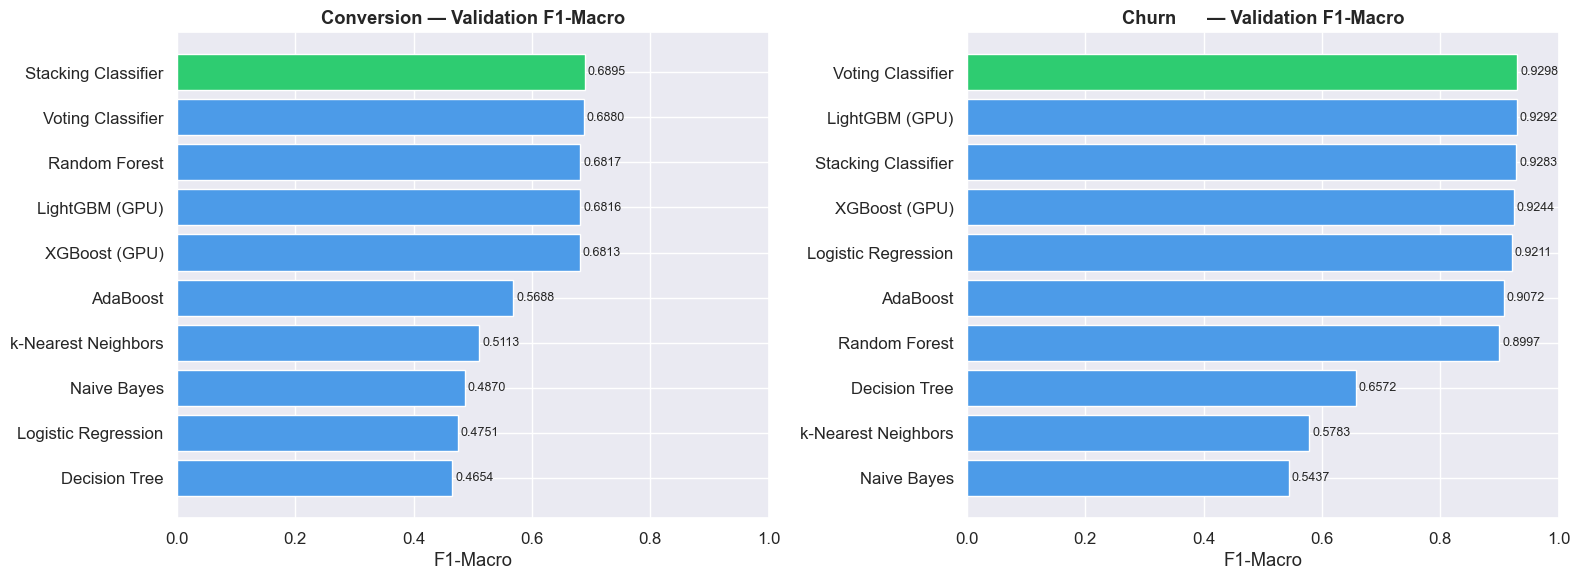

Plot saved ✓


In [10]:
df_conv  = pd.DataFrame(conv_results).sort_values('F1-Macro', ascending=False)
df_churn = pd.DataFrame(churn_results).sort_values('F1-Macro', ascending=False)

print('=' * 70)
print('  CONVERSION MODEL COMPARISON (Validation Set)')
print('=' * 70)
print(df_conv.to_string(index=False))

print()
print('=' * 70)
print('  CHURN MODEL COMPARISON (Validation Set)')
print('=' * 70)
print(df_churn.to_string(index=False))

# ── Bar chart visualisation ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, df, title in [
    (axes[0], df_conv,  'Conversion — Validation F1-Macro'),
    (axes[1], df_churn, 'Churn      — Validation F1-Macro'),
]:
    colors = ['#2ECC71' if i == 0 else '#4C9BE8' for i in range(len(df))]
    ax.barh(df['Model'], df['F1-Macro'], color=colors, edgecolor='white')
    ax.set_xlabel('F1-Macro')
    ax.set_title(title, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.invert_yaxis()
    for j, v in enumerate(df['F1-Macro']):
        ax.text(v + 0.005, j, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/02_validation_leaderboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved ✓')

## Section 10 — Threshold Optimization

The default 0.5 threshold is suboptimal for imbalanced data.  
We sweep thresholds on the **validation set** and pick the value that maximises **F1 for Class 0** (the minority class in both targets).

In [11]:
def find_best_threshold(model, X_val, y_val, target_class: int = 0) -> float:
    """
    Sweep 99 candidate thresholds on [0.01, 0.99].
    Returns the threshold that maximises F1 for `target_class`.
    """
    y_proba = model.predict_proba(X_val)[:, 1]
    best_thresh, best_f1 = 0.5, 0.0
    for t in np.linspace(0.01, 0.99, 99):
        preds = (y_proba >= t).astype(int)
        f1    = f1_score(y_val, preds, pos_label=target_class, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thresh = f1, t
    return float(best_thresh)

# ── Retrain final models (cloned stacking) on balanced train sets ─────────────
print('Cloning & training final stacking classifiers...')
best_model_conv  = clone(stacking_clf)
best_model_churn = clone(stacking_clf)

best_model_conv.fit(X_train_conv_bal,   y_train_conv_bal)
print('  Conversion model trained ✓')
best_model_churn.fit(X_train_churn_bal, y_train_churn_bal)
print('  Churn model trained ✓')

# ── Threshold search on validation set ────────────────────────────────────────
print('\nOptimizing decision thresholds on validation set...')
t_opt_conv  = find_best_threshold(best_model_conv,  X_val_conv,  y_val_conv,  target_class=0)
t_opt_churn = find_best_threshold(best_model_churn, X_val_churn, y_val_churn, target_class=0)

print(f'  Conversion threshold  : {t_opt_conv:.4f}  '
      f'(P(delivered) >= {t_opt_conv:.4f} → predict delivered)')
print(f'  Churn threshold       : {t_opt_churn:.4f}  '
      f'(P(churn) >= {t_opt_churn:.4f} → predict churned)')

Cloning & training final stacking classifiers...


  Conversion model trained ✓


  Churn model trained ✓

Optimizing decision thresholds on validation set...


  Conversion threshold  : 0.4000  (P(delivered) >= 0.4000 → predict delivered)
  Churn threshold       : 0.2900  (P(churn) >= 0.2900 → predict churned)


## Section 11 — Test Set Evaluation

In [12]:
def test_report(model, X_test, y_test, threshold, label):
    y_proba       = model.predict_proba(X_test)[:, 1]
    y_pred_def    = model.predict(X_test)
    y_pred_opt    = (y_proba >= threshold).astype(int)

    print(f'\n{"="*55}')
    print(f'  {label.upper()} — Default threshold (0.50)')
    print(f'{"="*55}')
    print(classification_report(y_test, y_pred_def, zero_division=0))

    print(f'{"="*55}')
    print(f'  {label.upper()} — Optimised threshold ({threshold:.4f})')
    print(f'{"="*55}')
    print(classification_report(y_test, y_pred_opt, zero_division=0))

    return y_proba, y_pred_opt

y_test_proba_conv,  y_test_pred_conv  = test_report(
    best_model_conv,  X_test_conv,  y_test_conv,  t_opt_conv,  'Conversion')

y_test_proba_churn, y_test_pred_churn = test_report(
    best_model_churn, X_test_churn, y_test_churn, t_opt_churn, 'Churn')


  CONVERSION — Default threshold (0.50)
              precision    recall  f1-score   support

           0       0.89      0.26      0.40       325
           1       0.98      1.00      0.99     10952

    accuracy                           0.98     11277
   macro avg       0.94      0.63      0.70     11277
weighted avg       0.98      0.98      0.97     11277

  CONVERSION — Optimised threshold (0.4000)
              precision    recall  f1-score   support

           0       0.89      0.26      0.40       325
           1       0.98      1.00      0.99     10952

    accuracy                           0.98     11277
   macro avg       0.94      0.63      0.70     11277
weighted avg       0.98      0.98      0.97     11277




  CHURN — Default threshold (0.50)
              precision    recall  f1-score   support

           0       0.98      0.80      0.88      2800
           1       0.94      0.99      0.96      8477

    accuracy                           0.95     11277
   macro avg       0.96      0.90      0.92     11277
weighted avg       0.95      0.95      0.94     11277

  CHURN — Optimised threshold (0.2900)
              precision    recall  f1-score   support

           0       0.99      0.79      0.88      2800
           1       0.94      1.00      0.97      8477

    accuracy                           0.95     11277
   macro avg       0.96      0.90      0.92     11277
weighted avg       0.95      0.95      0.94     11277



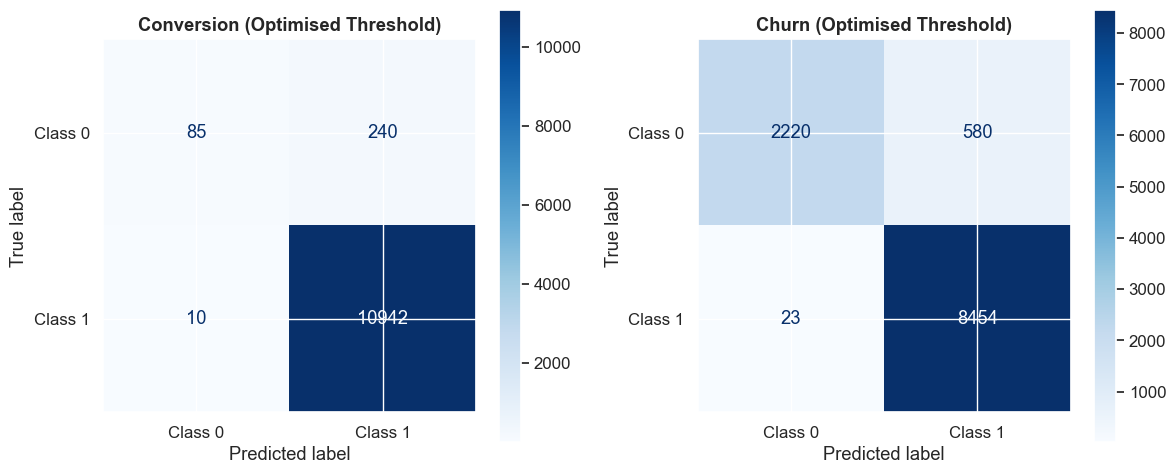

Confusion matrix plot saved ✓


In [13]:
# ── Confusion matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, model, X_te, y_te, threshold, title in [
    (axes[0], best_model_conv,  X_test_conv,  y_test_conv,
     t_opt_conv,  'Conversion (Optimised Threshold)'),
    (axes[1], best_model_churn, X_test_churn, y_test_churn,
     t_opt_churn, 'Churn (Optimised Threshold)'),
]:
    y_pred = (model.predict_proba(X_te)[:, 1] >= threshold).astype(int)
    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred,
        display_labels=['Class 0', 'Class 1'],
        cmap='Blues', ax=ax
    )
    ax.set_title(title, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/02_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrix plot saved ✓')

## Section 12 — ROC & Precision-Recall Curves

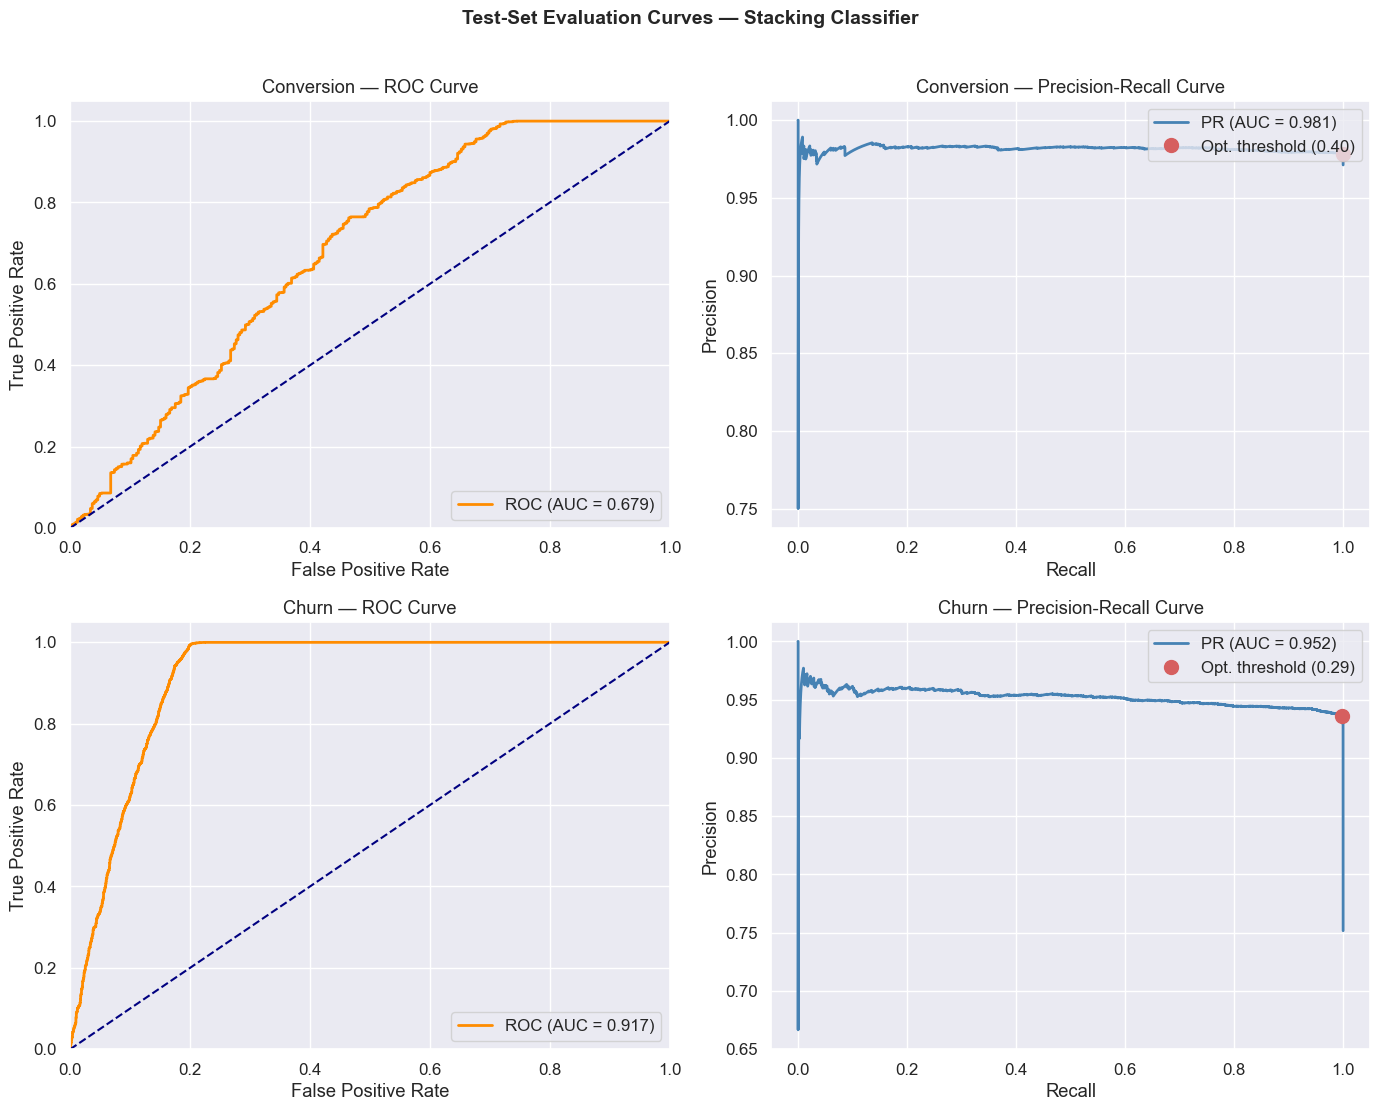

ROC & PR curves saved ✓


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

configs = [
    # (ax,        y_true,       y_proba,            opt_thresh,  label)
    (axes[0, 0], y_test_conv,  y_test_proba_conv,  t_opt_conv,  'Conversion'),
    (axes[1, 0], y_test_churn, y_test_proba_churn, t_opt_churn, 'Churn'),
    (axes[0, 1], y_test_conv,  y_test_proba_conv,  t_opt_conv,  'Conversion'),
    (axes[1, 1], y_test_churn, y_test_proba_churn, t_opt_churn, 'Churn'),
]

# ── ROC curves (left column) ──────────────────────────────────────────────────
for ax, y_true, y_proba, thresh, label in configs[:2]:
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color='darkorange', lw=2,
            label=f'ROC (AUC = {roc_auc:.3f})')
    ax.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
    ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate',
           title=f'{label} — ROC Curve', xlim=[0, 1], ylim=[0, 1.05])
    ax.legend(loc='lower right')

# ── PR curves (right column) ──────────────────────────────────────────────────
for ax, y_true, y_proba, thresh, label in configs[2:]:
    prec, rec, thresholds = precision_recall_curve(y_true, y_proba)
    pr_auc                = auc(rec, prec)

    # Find the precision/recall at the optimised threshold
    idx       = np.argmin(np.abs(thresholds - thresh)) if len(thresholds) else 0
    p_opt, r_opt = prec[idx], rec[idx]

    ax.plot(rec, prec, color='steelblue', lw=2,
            label=f'PR (AUC = {pr_auc:.3f})')
    ax.plot(r_opt, p_opt, 'ro', markersize=10,
            label=f'Opt. threshold ({thresh:.2f})')
    ax.set(xlabel='Recall', ylabel='Precision',
           title=f'{label} — Precision-Recall Curve')
    ax.legend(loc='upper right')

plt.suptitle('Test-Set Evaluation Curves — Stacking Classifier',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/02_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('ROC & PR curves saved ✓')

## Section 13 — Model Persistence

In [15]:
# ── Custom transformer (must be defined for joblib to serialise) ──────────────
class OutlierCapper(BaseEstimator, TransformerMixin):
    """Clip numerical features to [lower_quantile, upper_quantile] bounds."""

    def __init__(self, lower_quantile=0.01, upper_quantile=0.99):
        self.lower_quantile = lower_quantile
        self.upper_quantile = upper_quantile
        self.lower_bounds_  = {}
        self.upper_bounds_  = {}

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        for col in X_df.columns:
            if pd.api.types.is_numeric_dtype(X_df[col]):
                self.lower_bounds_[col] = X_df[col].quantile(self.lower_quantile)
                self.upper_bounds_[col] = X_df[col].quantile(self.upper_quantile)
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X).copy()
        for col in X_df.columns:
            if col in self.lower_bounds_:
                X_df[col] = X_df[col].clip(
                    lower=self.lower_bounds_[col],
                    upper=self.upper_bounds_[col],
                )
        return X_df.values if isinstance(X, np.ndarray) else X_df

# ── Save Conversion model ─────────────────────────────────────────────────────
joblib.dump({
    'model':     best_model_conv,
    'features':  list(X_train_conv_bal.columns),
    'threshold': t_opt_conv,
}, f'{MODEL_DIR}/conversion_stacking_model.joblib')
print(f'Saved {MODEL_DIR}/conversion_stacking_model.joblib')

# ── Save Churn model ──────────────────────────────────────────────────────────
joblib.dump({
    'model':     best_model_churn,
    'features':  list(X_train_churn_bal.columns),
    'threshold': t_opt_churn,
}, f'{MODEL_DIR}/churn_stacking_model.joblib')
print(f'Saved {MODEL_DIR}/churn_stacking_model.joblib')

# ── Summary ───────────────────────────────────────────────────────────────────
import os as _os
print('\nSaved artefacts:')
for f in sorted(_os.listdir(MODEL_DIR)):
    size_kb = _os.path.getsize(f'{MODEL_DIR}/{f}') / 1024
    print(f'  {MODEL_DIR}/{f}  ({size_kb:.1f} KB)')

Saved models/conversion_stacking_model.joblib


Saved models/churn_stacking_model.joblib

Saved artefacts:
  models/churn_stacking_model.joblib  (404174.0 KB)
  models/conversion_stacking_model.joblib  (254642.4 KB)
  models/preprocessor_pipeline.joblib  (21.9 KB)
  models/segmentation_gmm.joblib  (3.6 KB)
  models/segmentation_kmeans.joblib  (376.8 KB)
  models/segmentation_pca.joblib  (2.4 KB)
  models/segmentation_scaler.joblib  (0.8 KB)


## Section 14 — Inference Pipeline & Business Actions

Demonstrates loading the persisted artefacts and running end-to-end predictions on two sample customer records, mapping model scores to concrete operational interventions.

In [16]:
# ── Load preprocessing artefacts ─────────────────────────────────────────────
prep_data     = joblib.load(f'{MODEL_DIR}/preprocessor_pipeline.joblib')
preprocessor  = prep_data['preprocessor']
to_drop       = prep_data['to_drop']
selector      = prep_data['selector']
selected_cols = prep_data['selected_cols']
num_features  = prep_data['num_features']
cat_features  = prep_data['cat_features']

# ── Load models & thresholds ─────────────────────────────────────────────────
conv_pack  = joblib.load(f'{MODEL_DIR}/conversion_stacking_model.joblib')
churn_pack = joblib.load(f'{MODEL_DIR}/churn_stacking_model.joblib')

model_conv,  t_conv,  conv_features  = (conv_pack['model'],
                                         conv_pack['threshold'],
                                         conv_pack['features'])
model_churn, t_churn, churn_features = (churn_pack['model'],
                                         churn_pack['threshold'],
                                         churn_pack['features'])

# ── Sample records for demo ───────────────────────────────────────────────────
test_raw_data  = pd.read_csv(f'{OUTPUT_DIR}/test_raw_engineered.csv.gz', index_col=0)
sample_records = test_raw_data.iloc[[5, 20]].copy()
print(f'Loaded {len(sample_records)} sample records for inference demo')

print('Preprocessing artefacts loaded ✓')

Loaded 2 sample records for inference demo
Preprocessing artefacts loaded ✓


In [17]:
def run_inference_pipeline(raw_records: pd.DataFrame) -> pd.DataFrame:
    """
    Full inference pipeline:
      raw record → preprocessor → feature align → predict → threshold.
    Returns a DataFrame with probabilities and binary predictions.
    """
    rows = []
    for _, row in raw_records.iterrows():
        row_df = pd.DataFrame([row])

        # 1. Transform via ColumnTransformer
        proc_arr = preprocessor.transform(row_df)

        # 2. Reconstruct column names
        cat_encoder    = preprocessor.named_transformers_['cat'].named_steps['encoder']
        cat_cols       = cat_encoder.get_feature_names_out(cat_features).tolist()
        num_imputer    = preprocessor.named_transformers_['num'].named_steps['imputer']
        indicator_cols = (
            [f'missing_{num_features[i]}' for i in num_imputer.indicator_.features_]
            if getattr(num_imputer, 'add_indicator', False) else []
        )
        all_cols = num_features + indicator_cols + cat_cols
        proc_df  = pd.DataFrame(proc_arr, columns=all_cols, index=row_df.index)

        # 3. Drop collinear columns & apply variance threshold selection
        proc_sel = proc_df.drop(columns=[c for c in to_drop if c in proc_df.columns])
        final_df = proc_sel[selected_cols]

        # 4. Subset features expected by each model
        X_conv  = final_df[conv_features]
        X_churn = final_df[churn_features]

        # 5. Predict probabilities & apply thresholds
        prob_conv  = model_conv.predict_proba(X_conv)[0, 1]
        prob_churn = model_churn.predict_proba(X_churn)[0, 1]

        rows.append({
            'customer_id':       row['customer_unique_id'],
            'order_id':          row['order_id'],
            'price':             row['price'],
            'prob_delivered':    round(float(prob_conv),  4),
            'pred_delivered':    int(prob_conv  >= t_conv),
            'prob_churn':        round(float(prob_churn), 4),
            'pred_churn':        int(prob_churn >= t_churn),
        })
    return pd.DataFrame(rows)


predictions = run_inference_pipeline(sample_records)
print('\n=== Inference Results ===')
print(predictions.to_string(index=False))


=== Inference Results ===
                     customer_id                         order_id  price  prob_delivered  pred_delivered  prob_churn  pred_churn
781ae350edb16842380e81d7c7feb431 6a0a8bfbbe700284feb0845d95e0867f  83.90          0.9964               1      0.9711           1
cab5ecc01e69aac95f48b619eb40a882 75351e48296ef42211a0b80c427aae57  87.37          0.9951               1      0.9505           1


In [18]:
# ── Actionable business interventions ────────────────────────────────────────
print('\n=== Actionable Business Interventions ===')
for _, r in predictions.iterrows():
    cid = r['customer_id'][:8]
    oid = r['order_id'][:8]
    print(f'\n[Customer: {cid}... | Order: {oid}...]')

    # Delivery / SLA risk
    if r['pred_delivered'] == 0:
        print(f'  ⚠  SLA RISK (P(delivered)={r["prob_delivered"]:.2%})')
        print('     → Route to premium logistics partner; send proactive shipping SMS.')
    else:
        print(f'  ✓  Delivery healthy (P(delivered)={r["prob_delivered"]:.2%})')

    # Churn / retention
    if r['pred_churn'] == 1:
        print(f'  ⚠  CHURN RISK (P(churn)={r["prob_churn"]:.2%})')
        print('     → Trigger re-engagement email; offer personalised discount voucher.')
    else:
        print(f'  ✓  Loyal customer profile (P(churn)={r["prob_churn"]:.2%})')
        print('     → Enroll in VIP Loyalty programme; assign dedicated success manager.')


=== Actionable Business Interventions ===

[Customer: 781ae350... | Order: 6a0a8bfb...]
  ✓  Delivery healthy (P(delivered)=99.64%)
  ⚠  CHURN RISK (P(churn)=97.11%)
     → Trigger re-engagement email; offer personalised discount voucher.

[Customer: cab5ecc0... | Order: 75351e48...]
  ✓  Delivery healthy (P(delivered)=99.51%)
  ⚠  CHURN RISK (P(churn)=95.05%)
     → Trigger re-engagement email; offer personalised discount voucher.


## Summary

In [19]:
print('=' * 65)
print('  NOTEBOOK 02 — CHURN & CONVERSION CLASSIFICATION — COMPLETE')
print('=' * 65)

best_conv  = df_conv.iloc[0]
best_churn = df_churn.iloc[0]

print(f'\n  Best Conversion model : {best_conv["Model"]}')
print(f'    Val F1-Macro        : {best_conv["F1-Macro"]}')
print(f'    Val PR-AUC          : {best_conv["PR-AUC"]}')
print(f'    Optimised threshold : {t_opt_conv:.4f}')

print(f'\n  Best Churn model      : {best_churn["Model"]}')
print(f'    Val F1-Macro        : {best_churn["F1-Macro"]}')
print(f'    Val PR-AUC          : {best_churn["PR-AUC"]}')
print(f'    Optimised threshold : {t_opt_churn:.4f}')

print(f'\n  Plots saved to  : {PLOT_DIR}/')
print(f'  Models saved to : {MODEL_DIR}/')
print('\n  Next → Notebook 03: Demand Forecasting & Regression')
print('=' * 65)

  NOTEBOOK 02 — CHURN & CONVERSION CLASSIFICATION — COMPLETE

  Best Conversion model : Stacking Classifier
    Val F1-Macro        : 0.6895
    Val PR-AUC          : 0.9839
    Optimised threshold : 0.4000

  Best Churn model      : Voting Classifier
    Val F1-Macro        : 0.9298
    Val PR-AUC          : 0.9568
    Optimised threshold : 0.2900

  Plots saved to  : plots/
  Models saved to : models/

  Next → Notebook 03: Demand Forecasting & Regression
